# Imports and settings

In [ ]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Polygon
from statsmodels.stats.multitest import multipletests

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["axes.linewidth"] = 1.0

MODEL_LABEL = {
    "DNABERT": "DNABERT", "DNABERT2": "DNABERT-2",
    "NTv2": "Nucleotide\nTransformer V2", "NTv3": "Nucleotide\nTransformer V3",
    "Evo 2": "Evo 2", "HyenaDNA": "HyenaDNA", "PhyloGPN": "PhyloGPN"
}

TASK_ORDER = ["ZS", "ClinVar", "gnomAD", "BEND", "NCRE"]
TASK_LABEL = {
    "ZS": "Zero-shot", "ClinVar": "ClinVar Missense",
    "gnomAD": "gnomAD Variants", "BEND": "BEND Non-coding", "NCRE": "Regulatory Elements"
}

def get_text_color(bg_color):
    r, g, b = mcolors.to_rgb(bg_color)
    return "white" if (0.299*r + 0.587*g + 0.114*b) < 0.55 else "black"

def process_attn_clr(df):
    df = df.copy()
    df["vcf_iid"] = df["vcf_iid"].astype(str).str.strip()
    df["variant"] = df["variant"].astype(str).str.strip()
    log_a = np.log(pd.to_numeric(df["attention"], errors="coerce").clip(lower=1e-12))
    df["attn_clr"] = log_a - df.groupby("vcf_iid")["attention"].transform(lambda x: np.log(x.clip(1e-12)).mean())
    return df.set_index(["vcf_iid", "variant"])["attn_clr"]

# Loading attention scores

In [ ]:
ATTN_ROOT = "/path/to/attn"

# DNABERT
zs_dnabert_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert_zs_attn.csv")
ft_dnabert_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_ncre_attn.csv")
ft_dnabert_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_bend_attn.csv")
ft_dnabert_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_clinvar_attn.csv")
ft_dnabert_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert/dnabert_ft_gnomad_attn.csv")

# DNABERT2
zs_dnabert2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/dnabert2_zs_attn.csv")
ft_dnabert2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_ncre_attn.csv")
ft_dnabert2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_bend_attn.csv")
ft_dnabert2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_clinvar_attn.csv")
ft_dnabert2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/dnabert2/dnabert2_ft_gnomad_attn.csv")

# NTv2
zs_ntv2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv2_zs_attn.csv")
ft_ntv2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_ncre_attn.csv")
ft_ntv2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_bend_attn.csv")
ft_ntv2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_clinvar_attn.csv")
ft_ntv2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv2/ntv2_ft_gnomad_attn.csv")

# NTv3
zs_ntv3_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/ntv3_zs_attn.csv")
ft_ntv3_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_ncre_attn.csv")
ft_ntv3_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_bend_attn.csv")
ft_ntv3_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_clinvar_attn.csv")
ft_ntv3_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/ntv3/ntv3_ft_gnomad_attn.csv")

# HyenaDNA
zs_hyena_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/hyenadna_zs_attn.csv")
ft_hyena_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_ncre_attn.csv")
ft_hyena_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_bend_attn.csv")
ft_hyena_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_clinvar_attn.csv")
ft_hyena_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/hyenadna/hyenadna_ft_gnomad_attn.csv")

# evo2
zs_evo2_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/evo2_zs_attn.csv")
ft_evo2_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_ncre_attn.csv")
ft_evo2_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_bend_attn.csv")
ft_evo2_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_clinvar_attn.csv")
ft_evo2_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/evo2/evo2_ft_gnomad_attn.csv")

# PhyloGPN
zs_phylogpn_attn         = pd.read_csv(f"{ATTN_ROOT}/zeroshot/phylogpn_zs_attn.csv")
ft_phylogpn_ncre_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_ncre_attn.csv")
ft_phylogpn_bend_attn    = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_bend_attn.csv")
ft_phylogpn_clinvar_attn = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_clinvar_attn.csv")
ft_phylogpn_gnomad_attn  = pd.read_csv(f"{ATTN_ROOT}/finetuned/phylogpn/phylogpn_ft_gnomad_attn.csv")


model_tasks_raw = {
    "DNABERT":  {"ZS": zs_dnabert_attn,  "NCRE": ft_dnabert_ncre_attn,  "BEND": ft_dnabert_bend_attn,  "ClinVar": ft_dnabert_clinvar_attn,  "gnomAD": ft_dnabert_gnomad_attn},
    "DNABERT2": {"ZS": zs_dnabert2_attn, "NCRE": ft_dnabert2_ncre_attn, "BEND": ft_dnabert2_bend_attn, "ClinVar": ft_dnabert2_clinvar_attn, "gnomAD": ft_dnabert2_gnomad_attn},
    "NTv2":     {"ZS": zs_ntv2_attn,     "NCRE": ft_ntv2_ncre_attn,     "BEND": ft_ntv2_bend_attn,     "ClinVar": ft_ntv2_clinvar_attn,     "gnomAD": ft_ntv2_gnomad_attn},
    "NTv3":     {"ZS": zs_ntv3_attn,     "NCRE": ft_ntv3_ncre_attn,     "BEND": ft_ntv3_bend_attn,     "ClinVar": ft_ntv3_clinvar_attn,     "gnomAD": ft_ntv3_gnomad_attn},
    "HyenaDNA": {"ZS": zs_hyena_attn,    "NCRE": ft_hyena_ncre_attn,    "BEND": ft_hyena_bend_attn,    "ClinVar": ft_hyena_clinvar_attn,    "gnomAD": ft_hyena_gnomad_attn},
    "Evo 2":    {"ZS": zs_evo2_attn,    "NCRE": ft_evo2_ncre_attn,    "BEND": ft_evo2_bend_attn,    "ClinVar": ft_evo2_clinvar_attn,    "gnomAD": ft_evo2_gnomad_attn},
    "PhyloGPN": {"ZS": zs_phylogpn_attn, "NCRE": ft_phylogpn_ncre_attn, "BEND": ft_phylogpn_bend_attn, "ClinVar": ft_phylogpn_clinvar_attn, "gnomAD": ft_phylogpn_gnomad_attn},
}

model_tasks_attn = {}
for m, tasks in model_tasks_raw.items():
    model_tasks_attn[m] = {}
    for t, df in tasks.items():
        model_tasks_attn[m][t] = process_attn_clr(df)
    print(f"[PROCESS] CLR transformation completed for {m}")

print("\n[DONE] All attention scores are loaded and pre-processed.")

# Consequence based analysis

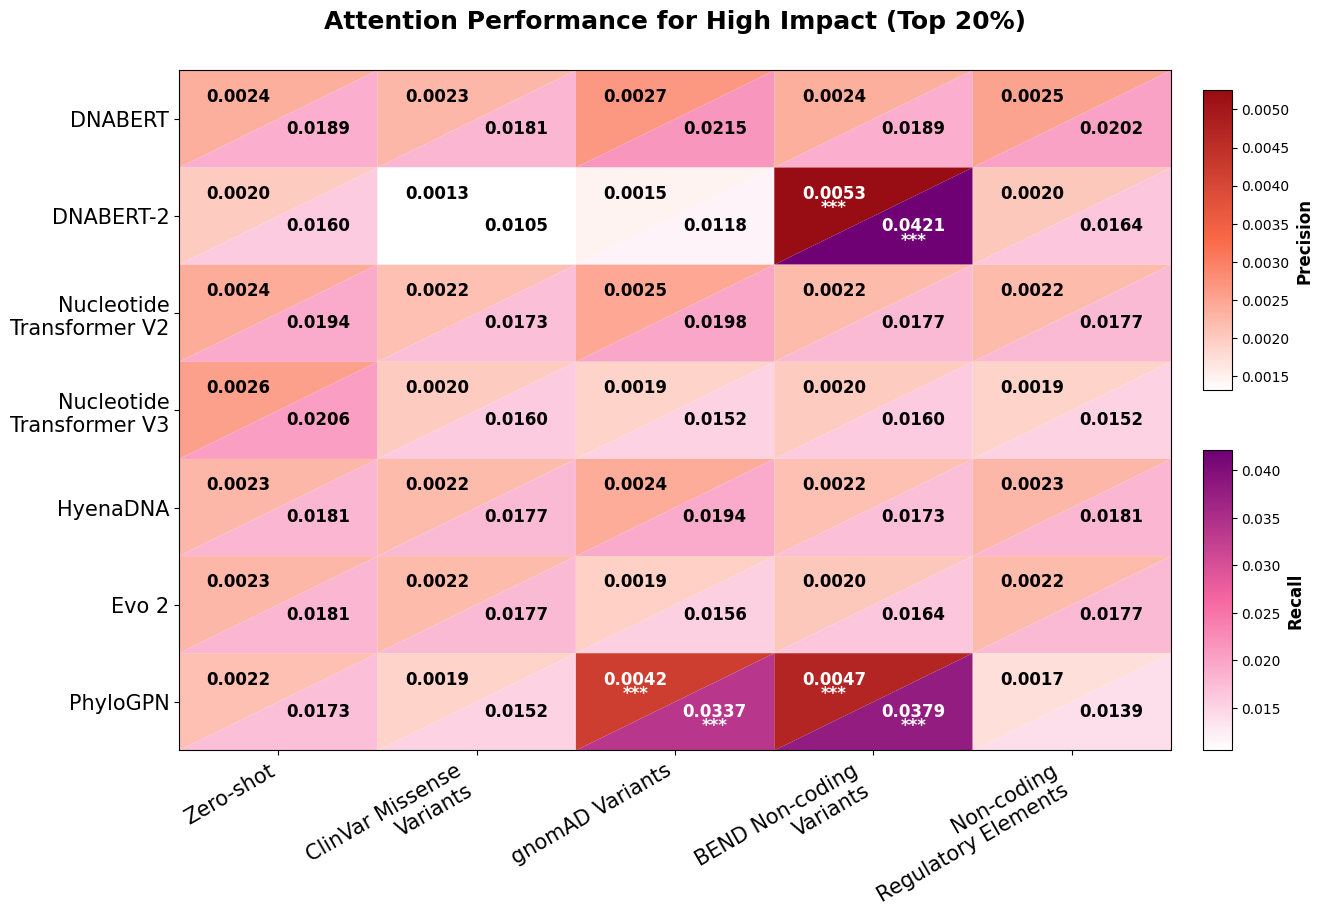

In [ ]:
DNV_PATH = "/path/to/data/variant.feather"
dnv = pd.read_feather(DNV_PATH)
dnv["vcf_iid"] = dnv["vcf_iid"].astype(str).str.strip()
dnv["variant"] = dnv["variant"].astype(str).str.strip()

high_impact_df = dnv[dnv["most_severe_consequence"].isin([
    "transcript_ablation", "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained", "frameshift_variant", "stop_lost", "start_lost"
])]
target_consequence = set(zip(high_impact_df["vcf_iid"], high_impact_df["variant"]))

def analyze_and_plot(target_set, title_suffix, k=20):
    models = list(model_tasks_attn.keys())
    tasks = TASK_ORDER
    
    res = {met: pd.DataFrame(index=models, columns=tasks, dtype=float) for met in ["P", "R", "PV_P", "PV_R"]}
    
    for m in models:
        s_zs = model_tasks_attn[m]["ZS"]
        top_zs = set(s_zs[s_zs >= np.percentile(s_zs, 100-k)].index)
        zs_hit = len(top_zs & target_set)
        zs_total_target = len(set(s_zs.index) & target_set)
        
        for t in tasks:
            s_ft = model_tasks_attn[m].get(t)
            if s_ft is None: continue
            
            top_ft = set(s_ft[s_ft >= np.percentile(s_ft, 100-k)].index)
            ft_hit = len(top_ft & target_set)
            ft_total_target = len(set(s_ft.index) & target_set)
            
            res["P"].loc[m, t] = ft_hit / len(top_ft) if top_ft else 0
            res["R"].loc[m, t] = ft_hit / ft_total_target if ft_total_target else 0
            
            _, p_p = stats.fisher_exact([[ft_hit, len(top_ft)-ft_hit], [zs_hit, len(top_zs)-zs_hit]])
            _, p_r = stats.fisher_exact([[ft_hit, ft_total_target-ft_hit], [zs_hit, zs_total_target-zs_hit]])
            res["PV_P"].loc[m, t] = p_p
            res["PV_R"].loc[m, t] = p_r

    fig, ax = plt.subplots(figsize=(16, 10))
    plt.subplots_adjust(left=0.2, right=0.82, bottom=0.2, top=0.88)
    
    sm_p = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=Normalize(vmin=res["P"].min().min(), vmax=res["P"].max().max()))
    sm_r = plt.cm.ScalarMappable(cmap=plt.cm.RdPu, norm=Normalize(vmin=res["R"].min().min(), vmax=res["R"].max().max()))

    for i, m in enumerate(models):
        for j, t in enumerate(tasks):
            vp, vr = res["P"].loc[m, t], res["R"].loc[m, t]
            pp, pr = res["PV_P"].loc[m, t], res["PV_R"].loc[m, t]
            
            cp, cr = sm_p.to_rgba(vp), sm_r.to_rgba(vr)
            ax.add_patch(Polygon([[j-0.5, i-0.5], [j+0.5, i-0.5], [j-0.5, i+0.5]], facecolor=cp))
            ax.add_patch(Polygon([[j+0.5, i+0.5], [j+0.5, i-0.5], [j-0.5, i+0.5]], facecolor=cr))

            sp = "***" if pp<0.001 else "**" if pp<0.01 else "*" if pp<0.05 else ""
            sr = "***" if pr<0.001 else "**" if pr<0.01 else "*" if pr<0.05 else ""
            
            ax.text(j-0.2, i-0.18, f"{vp:.4f}", ha='center', fontsize=12, fontweight='bold', color=get_text_color(cp))
            ax.text(j+0.2, i+0.15, f"{vr:.4f}", ha='center', fontsize=12, fontweight='bold', color=get_text_color(cr))
            if sp: ax.text(j-0.2, i-0.03, sp, ha='center', fontsize=12, color=get_text_color(cp))
            if sr: ax.text(j+0.2, i+0.30, sr, ha='center', fontsize=12, color=get_text_color(cr))

    ax.set_xticks(range(len(tasks))); ax.set_xticklabels([TASK_LABEL[t] for t in tasks], rotation=30, ha='right', fontsize=15)
    ax.set_yticks(range(len(models))); ax.set_yticklabels([MODEL_LABEL[m] for m in models], fontsize=15)
    ax.set_title(f"Attention Performance: {title_suffix} (Top {k}%)", fontsize=18, fontweight='bold', pad=30)
    ax.set_ylim(len(models)-0.5, -0.5)

    cax_p = fig.add_axes([0.84, 0.56, 0.018, 0.30]); plt.colorbar(sm_p, cax=cax_p).set_label("Precision")
    cax_r = fig.add_axes([0.84, 0.20, 0.018, 0.30]); plt.colorbar(sm_r, cax=cax_r).set_label("Recall")
    plt.show()

analyze_and_plot(target_consequence, "High Impact Consequence")

# CADD based analysis

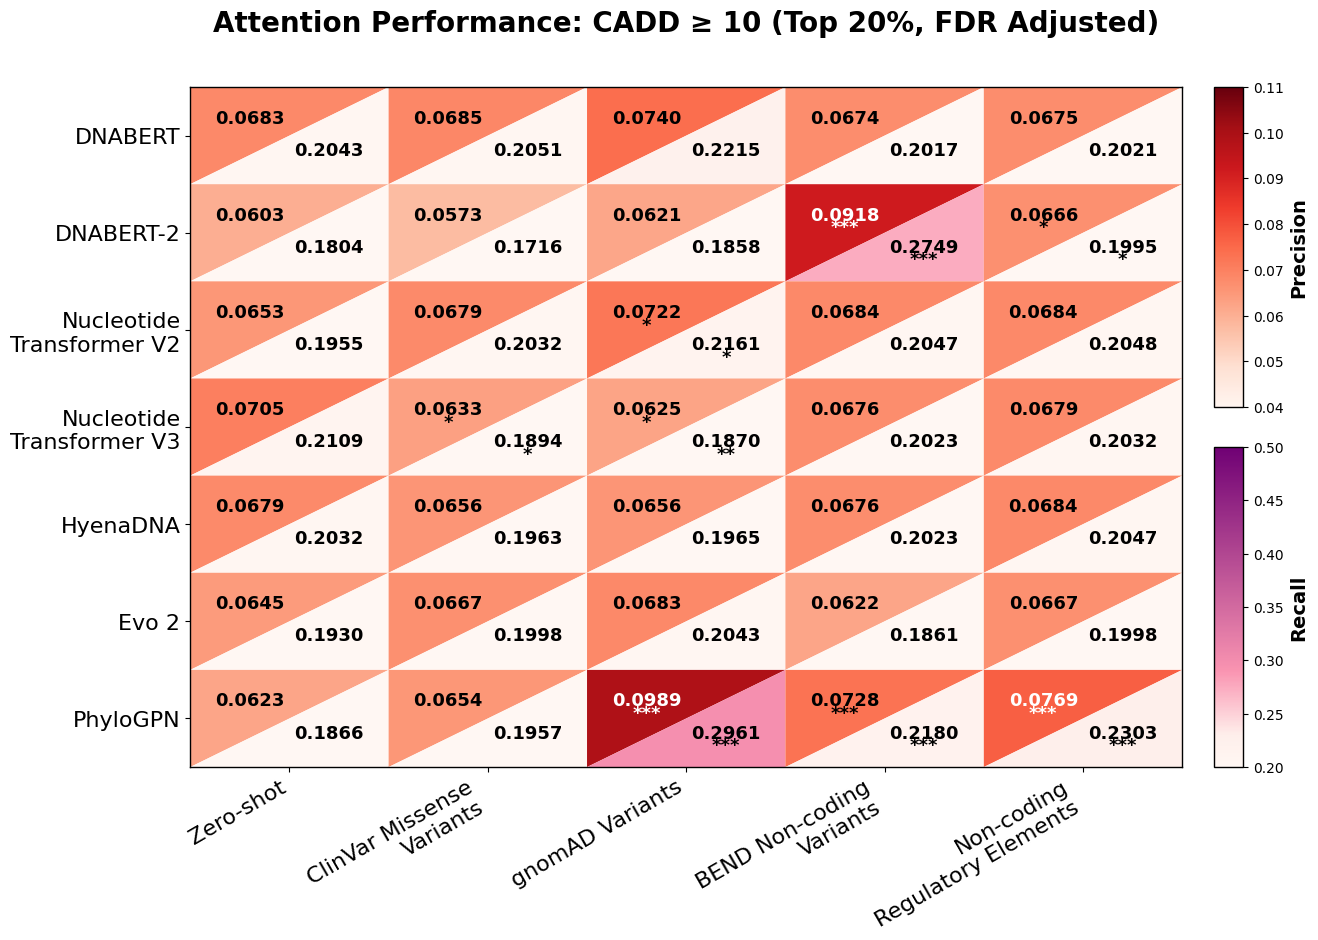

In [ ]:
dnv["CADD_phred"] = pd.to_numeric(dnv["CADD_phred"], errors="coerce")
target_cadd = set(zip(dnv[dnv["CADD_phred"] >= 10.0]["vcf_iid"], dnv[dnv["CADD_phred"] >= 10.0]["variant"]))

def analyze_cadd_fdr(target_set, k=20):
    models = list(model_tasks_attn.keys())
    tasks = TASK_ORDER
    res = {met: pd.DataFrame(index=models, columns=tasks, dtype=float) for met in ["P", "R", "PV_P", "PV_R"]}

    for m in models:
        s_zs = model_tasks_attn[m]["ZS"]
        top_zs = set(s_zs[s_zs >= np.percentile(s_zs, 100-k)].index)
        zs_hit = len(top_zs & target_set)
        zs_total_target = len(set(s_zs.index) & target_set)

        for t in tasks:
            s_ft = model_tasks_attn[m].get(t)
            if s_ft is None: continue
            top_ft = set(s_ft[s_ft >= np.percentile(s_ft, 100-k)].index)
            ft_hit = len(top_ft & target_set)
            ft_total_target = len(set(s_ft.index) & target_set)

            res["P"].loc[m, t] = ft_hit / len(top_ft) if top_ft else 0
            res["R"].loc[m, t] = ft_hit / ft_total_target if ft_total_target else 0
            _, p_p = stats.fisher_exact([[ft_hit, len(top_ft)-ft_hit], [zs_hit, len(top_zs)-zs_hit]])
            _, p_r = stats.fisher_exact([[ft_hit, ft_total_target-ft_hit], [zs_hit, zs_total_target-zs_hit]])
            res["PV_P"].loc[m, t] = p_p; res["PV_R"].loc[m, t] = p_r

    for p_type in ["PV_P", "PV_R"]:
        p_vals = res[p_type].values.flatten()
        _, adj_p, _, _ = multipletests(p_vals, method='fdr_bh')
        res[p_type] = pd.DataFrame(adj_p.reshape(len(models), len(tasks)), index=models, columns=tasks)

    fig, ax = plt.subplots(figsize=(16, 10))
    plt.subplots_adjust(left=0.2, right=0.82, bottom=0.2, top=0.88)
    
    sm_p = plt.cm.ScalarMappable(cmap=plt.cm.Reds, norm=Normalize(vmin=0.04, vmax=0.11))
    colors_r = [(0.0, "#ffffff"), (0.1, "#fde0ef"), (0.3, "#df97b0"), (1.0, "#980043")] # Custom RdPu
    cmap_r = LinearSegmentedColormap.from_list("custom_r", colors_r)
    sm_r = plt.cm.ScalarMappable(cmap=cmap_r, norm=Normalize(vmin=0.20, vmax=0.50))

    for i, m in enumerate(models):
        for j, t in enumerate(tasks):
            vp, vr = res["P"].loc[m, t], res["R"].loc[m, t]
            ap, ar = res["PV_P"].loc[m, t], res["PV_R"].loc[m, t]
            
            cp, cr = sm_p.to_rgba(vp), sm_r.to_rgba(vr)
            ax.add_patch(Polygon([[j-0.5, i-0.5], [j+0.5, i-0.5], [j-0.5, i+0.5]], facecolor=cp))
            ax.add_patch(Polygon([[j+0.5, i+0.5], [j+0.5, i-0.5], [j-0.5, i+0.5]], facecolor=cr))

            sp = "***" if ap<0.001 else "**" if ap<0.01 else "*" if ap<0.05 else ""
            sr = "***" if ar<0.001 else "**" if ar<0.01 else "*" if ar<0.05 else ""
            
            ax.text(j-0.2, i-0.18, f"{vp:.4f}", ha='center', fontsize=13, fontweight='bold', color=get_text_color(cp))
            ax.text(j+0.2, i+0.15, f"{vr:.4f}", ha='center', fontsize=13, fontweight='bold', color=get_text_color(cr))
            if sp: ax.text(j-0.2, i-0.05, sp, ha='center', fontsize=13, color=get_text_color(cp))
            if sr: ax.text(j+0.2, i+0.28, sr, ha='center', fontsize=13, color=get_text_color(cr))

    ax.set_xticks(range(len(tasks))); ax.set_xticklabels([TASK_LABEL[t] for t in tasks], rotation=30, ha='right', fontsize=16)
    ax.set_yticks(range(len(models))); ax.set_yticklabels([MODEL_LABEL[m] for m in models], fontsize=16)
    ax.set_title(f"Attention Performance: CADD $\ge$ 10 (Top {k}%, FDR Adjusted)", fontsize=20, fontweight='bold', pad=40)
    ax.set_ylim(len(models)-0.5, -0.5)

    cax_p = fig.add_axes([0.84, 0.56, 0.018, 0.32]); plt.colorbar(sm_p, cax=cax_p).set_label("Precision")
    cax_r = fig.add_axes([0.84, 0.20, 0.018, 0.32]); plt.colorbar(sm_r, cax=cax_r).set_label("Recall")
    plt.show()

analyze_cadd_fdr(target_cadd)